<!--Información del curso-->
<img align="left" style="padding-right:10px;" src="figuras/logo_cd.png">

<center><h1 style="font-size:2em;color:#2467C0"> Datos del INEGI  </h1></center>
<br>
<table>
<col width="550">
<col width="450">
<tr>
<td><img src="figuras/inegi.png" align="middle" style="width:500"/></td>
<td>
    
El **INEGI** es un organismo público autónomo responsable de normar y coordinar el Sistema Nacional de Información Estadística y Geográfica, así como de captar y difundir información de México en cuanto al territorio, los recursos, la población y economía, que permita dar a conocer las características de nuestro país y ayudar a la toma de decisiones.
    
</td>
</tr>
</table>

# API del Banco de Indicadores

La API de Indicadores del INEGI permite consultar los datos y metadatos de los indicadores disponibles a nivel nacional, por entidad federativa y municipio. Puede utilizar la API para crear aplicaciones que muestren la información directamente de las bases de datos del INEGI en el preciso momento en que se actualiza.
(https://www.inegi.org.mx/servicios/api_indicadores.html) 

<img src="figuras/Inegi_token.jpg" align="middle" style="width:1000px"/>


**Instalar:**

pip install requests

#  Historico de Población en México

<div class="alert alert-success">
1. Graficar el crecimiento de la población total, así como el de hombres y mujeres
</div>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import json                      

In [2]:
#Llamado al API
token = '2bd5155c-eb20-e751-782b-47cb8bd5fbef'
url = f'https://www.inegi.org.mx/app/api/indicadores/desarrolladores/jsonxml/INDICATOR/1002000001/es/00/true/BISE/2.0/{token}?type=json'
respuesta = requests.get(url)
respuesta.status_code

200

In [3]:
respuesta = requests.get(url)
if respuesta.status_code == 200:
    print(respuesta.content)

b'{"Header":{"Name":"Datos compactos BISE","Email":"atencion.usuarios@inegi.org.mx"},"Series":[{"INDICADOR":"1002000001","FREQ":"7","TOPIC":"123","UNIT":"188","UNIT_MULT":"","NOTE":"1398","SOURCE":"2,3,343,487,781,1668,1669,1670,1671,1672,1677,1678,1679,1714,3001","LASTUPDATE":"21/10/2024 12:00:00 a. m.","STATUS":null,"OBSERVATIONS":[{"TIME_PERIOD":"2020","OBS_VALUE":"126014024.00000000000000000000","OBS_EXCEPTION":null,"OBS_STATUS":"3","OBS_SOURCE":"","OBS_NOTE":"","COBER_GEO":"0"}]}]}'


In [4]:
content = respuesta.json()

int(float(content['Series'][0]['OBSERVATIONS'][0]['OBS_VALUE']))

126014024

In [5]:
url_historica=f'https://www.inegi.org.mx/app/api/indicadores/desarrolladores/jsonxml/INDICATOR/1002000001/es/00/false/BISE/2.0/{token}?type=json'
respuesta_hist = requests.get(url=url_historica)

if respuesta_hist.status_code == 200:
    content_hist = respuesta_hist.json()

In [6]:
print(content_hist)

{'Header': {'Name': 'Datos compactos BISE', 'Email': 'atencion.usuarios@inegi.org.mx'}, 'Series': [{'INDICADOR': '1002000001', 'FREQ': '7', 'TOPIC': '123', 'UNIT': '188', 'UNIT_MULT': '', 'NOTE': '1398', 'SOURCE': '2,3,343,487,781,1668,1669,1670,1671,1672,1677,1678,1679,1714,3001', 'LASTUPDATE': '21/10/2024 12:00:00 a. m.', 'STATUS': None, 'OBSERVATIONS': [{'TIME_PERIOD': '1910', 'OBS_VALUE': '15160369.00000000000000000000', 'OBS_EXCEPTION': None, 'OBS_STATUS': '3', 'OBS_SOURCE': '', 'OBS_NOTE': '', 'COBER_GEO': '0'}, {'TIME_PERIOD': '1921', 'OBS_VALUE': '14334780.00000000000000000000', 'OBS_EXCEPTION': None, 'OBS_STATUS': '3', 'OBS_SOURCE': '', 'OBS_NOTE': '', 'COBER_GEO': '0'}, {'TIME_PERIOD': '1930', 'OBS_VALUE': '16552722.00000000000000000000', 'OBS_EXCEPTION': None, 'OBS_STATUS': '3', 'OBS_SOURCE': '', 'OBS_NOTE': '', 'COBER_GEO': '0'}, {'TIME_PERIOD': '1940', 'OBS_VALUE': '19653552.00000000000000000000', 'OBS_EXCEPTION': None, 'OBS_STATUS': '3', 'OBS_SOURCE': '', 'OBS_NOTE': '', 

In [7]:
poblacion_anio = []
poblacion_total = []
for valor in content_hist['Series'][0]['OBSERVATIONS']:
    poblacion_anio.append(int(valor['TIME_PERIOD']))

for valor in content_hist['Series'][0]['OBSERVATIONS']:
    poblacion_total.append(float(valor['OBS_VALUE']))


print(poblacion_total)
print(poblacion_anio)

[15160369.0, 14334780.0, 16552722.0, 19653552.0, 25791017.0, 34923129.0, 48225238.0, 66846833.0, 81249645.0, 91158290.0, 97483412.0, 103263388.0, 112336538.0, 119938473.0, 126014024.0]
[1910, 1921, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 1995, 2000, 2005, 2010, 2015, 2020]


In [8]:
pob_df = pd.DataFrame(content_hist['Series'][0]['OBSERVATIONS'])[['TIME_PERIOD','OBS_VALUE']]
pob_df['TIME_PERIOD'] = [int(valor) for valor in pob_df['TIME_PERIOD']]
pob_df['OBS_VALUE'] = [float(valor) for valor in pob_df['OBS_VALUE']]

In [9]:
pob_df.set_index('TIME_PERIOD', inplace=True)

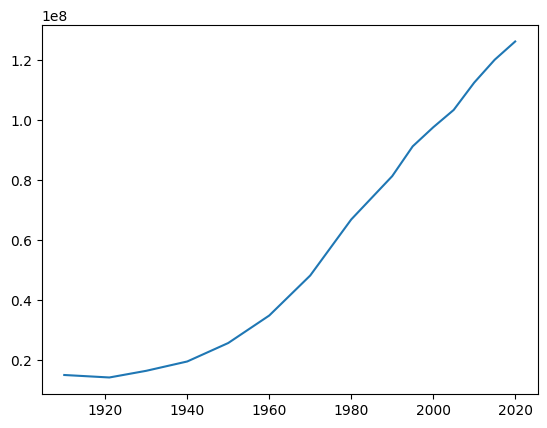

In [10]:
plt.plot(pob_df)

<div class="alert alert-success">
2. Mostrar en un mapa  el porcentaje de población de 12 años y más económicamente activa por estados. 
Utilizar alguna gama de color que a continuación se presenta.

</div>

<img align="left" style="padding-right:10px;" src="figuras/colores.png">


In [11]:
url_aguas= f'https://www.inegi.org.mx/app/api/indicadores/desarrolladores/jsonxml/INDICATOR/1002000001,6207019039/es/01/true/BISE/2.0/{token}?type=json'

respuesta_aguas = requests.get(url=url_aguas)

if respuesta_aguas.status_code == 200:
    content_aguas = respuesta_aguas.json()

content_aguas

{'Header': {'Name': 'Datos compactos BISE',
  'Email': 'atencion.usuarios@inegi.org.mx'},
 'Series': [{'INDICADOR': '1002000001',
   'FREQ': '7',
   'TOPIC': '123',
   'UNIT': '188',
   'UNIT_MULT': '',
   'NOTE': '1398',
   'SOURCE': '2,3,343,487,781,1668,1669,1670,1671,1672,1677,1678,1679,1714,3001',
   'LASTUPDATE': '21/10/2024 12:00:00 a. m.',
   'STATUS': None,
   'OBSERVATIONS': [{'TIME_PERIOD': '2020',
     'OBS_VALUE': '1425607.00000000000000000000',
     'OBS_EXCEPTION': None,
     'OBS_STATUS': '3',
     'OBS_SOURCE': '',
     'OBS_NOTE': '',
     'COBER_GEO': '01'}]},
  {'INDICADOR': '6207019039',
   'FREQ': '7',
   'TOPIC': '18',
   'UNIT': '3',
   'UNIT_MULT': '',
   'NOTE': '',
   'SOURCE': '1714,3001',
   'LASTUPDATE': '24/01/2021 12:00:00 a. m.',
   'STATUS': None,
   'OBSERVATIONS': [{'TIME_PERIOD': '2020',
     'OBS_VALUE': '98.02710310780420000000',
     'OBS_EXCEPTION': None,
     'OBS_STATUS': '3',
     'OBS_SOURCE': '',
     'OBS_NOTE': '',
     'COBER_GEO': '01'}

In [19]:
estados = [f'0{estado}' if estado < 10 else str(estado) for estado in range(1,33)]
estados

['01',
 '02',
 '03',
 '04',
 '05',
 '06',
 '07',
 '08',
 '09',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32']

In [ ]:
for estado in estados:
    url_estados = f'https://www.inegi.org.mx/app/api/indicadores/desarrolladores/jsonxml/INDICATOR/1002000001,6207019039/es/{estado}/true/BISE/2.0/{token}?type=json'
    
    respuesta_estados = requests.get(url_estados)
    
    if 